# Specific Stock Simulation

Get the historical daily data for one ticker, run the prediction analysis across the full history, simulate trades from the resulting daily signals, and show a consolidated chart with price, trade markers, and portfolio value.

Trading rules:
- `STRONG BUY`: buy stock worth 10% of `initial_funds`
- `WEAK BUY`: buy stock worth 5% of `initial_funds`
- `HOLD`: do nothing
- `WEAK SELL`: sell 5% of current holdings
- `STRONG SELL`: sell 10% of current holdings

Fractional shares are allowed.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import analysis_blocks


## Block 1: Parameters


In [2]:
ticker = "PDD"
initial_funds = 10000
include_fundamentals = True
include_sentiment = False  # True requires API keys and adds latency


In [3]:

df_pred = analysis_blocks.build_prediction_frame(
            ticker,
            include_sentiment=include_sentiment
        )
df_pred

,Date,Open,High,Low,Close,Adj Close,Volume,TICKER,SMA10,SMA20,...,VWAP,Daily_Return,Cumulative_Return,Daily Gain/Loss,technical_analysis_buy_score,technical_analysis_sell_score,fundamental_analysis_score,sentiment_analysis_score,Signal,Signal_Text
0,2026-03-13,102.529999,103.620003,102.129997,102.650002,102.650002,4075240,PDD,NaN,NaN,...,102.650002,NaN,NaN,0.120003,0.00,-0.04,0.8875,0,0.8595,WEAK BUY
1,2026-03-12,102.529999,103.889999,101.389999,101.620003,101.620003,6350800,PDD,NaN,NaN,...,102.022600,-0.010034,-0.010034,-0.909996,0.15,-0.07,0.8875,0,0.9435,STRONG BUY
2,2026-03-11,104.629997,104.750000,102.480003,102.940002,102.940002,4475300,PDD,NaN,NaN,...,102.298122,0.012990,0.002825,-1.689995,0.00,-0.22,0.8875,0,0.7335,WEAK BUY
3,2026-03-10,103.529999,106.570000,103.419998,104.860001,104.860001,7767100,PDD,NaN,NaN,...,103.175923,0.018652,0.021529,1.330002,0.03,-0.19,0.8875,0,0.7755,WEAK BUY
4,2026-03-09,101.010002,103.010002,99.680000,102.639999,102.639999,6374600,PDD,NaN,NaN,...,103.058294,-0.021171,-0.000097,1.629997,0.18,-0.04,0.8875,0,0.9855,STRONG BUY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1251,2021-03-19,141.070007,143.029999,138.199997,141.800003,141.800003,9457000,PDD,134.278999,135.837999,...,94.042509,0.033905,0.381393,0.729996,0.02,-0.20,0.8875,0,0.7615,WEAK BUY
1252,2021-03-18,144.710007,146.029999,140.520004,141.820007,141.820007,12125200,PDD,134.068000,136.263500,...,94.088945,0.000141,0.381588,-2.889999,0.02,-0.20,0.8875,0,0.7615,WEAK BUY
1253,2021-03-17,152.399994,153.000000,140.360001,149.460007,149.460007,27357800,PDD,135.626000,137.117500,...,94.210105,0.053871,0.456016,-2.939987,0.04,-0.18,0.8875,0,0.7895,WEAK BUY
1254,2021-03-16,166.800003,169.449997,158.699997,160.889999,160.889999,10963900,PDD,138.171000,138.531500,...,94.268527,0.076475,0.567365,-5.910004,0.05,-0.20,0.8875,0,0.7825,WEAK BUY


## Block 4: Simulate Daily Buy/Sell/Hold Strategy


In [4]:
simulation_result = analysis_blocks.simulate_prediction_signal_strategy(
    df_pred,
    initial_funds=initial_funds,
)


## Block 5: Portfolio Summary


In [5]:
simulation_result["price_history"]

,Date,Open,Close,Trade_Price
0,2021-03-15,158.699997,159.130005,158.915001
1,2021-03-16,166.800003,160.889999,163.845001
2,2021-03-17,152.399994,149.460007,150.930000
3,2021-03-18,144.710007,141.820007,143.265007
4,2021-03-19,141.070007,141.800003,141.435005
...,...,...,...,...
1251,2026-03-09,101.010002,102.639999,101.825001
1252,2026-03-10,103.529999,104.860001,104.195000
1253,2026-03-11,104.629997,102.940002,103.785000
1254,2026-03-12,102.529999,101.620003,102.075001


In [6]:
simulation_result["daily_history"]

,Date,Open,Close,Trade_Price,signal_text,signal_number,action,trade_units,trade_value,cash_balance,units_held,average_cost_per_unit,holdings_value,portfolio_value,profit_loss,profit_loss_pct
0,2021-03-15,158.699997,159.130005,158.915001,WEAK BUY,1,BUY,3.146336,500.0,9500.0,3.146336,158.915001,500.676475,10000.676475,0.676475,0.006765
1,2021-03-16,166.800003,160.889999,163.845001,WEAK BUY,1,BUY,3.051665,500.0,9000.0,6.198001,161.342349,997.196334,9997.196334,-2.803666,-0.028037
2,2021-03-17,152.399994,149.460007,150.930000,WEAK BUY,1,BUY,3.312794,500.0,8500.0,9.510795,157.715527,1421.483445,9921.483445,-78.516555,-0.785166
3,2021-03-18,144.710007,141.820007,143.265007,WEAK BUY,1,BUY,3.490036,500.0,8000.0,13.000831,153.836326,1843.777879,9843.777879,-156.222121,-1.562221
4,2021-03-19,141.070007,141.800003,141.435005,WEAK BUY,1,BUY,3.535193,500.0,7500.0,16.536023,151.185080,2344.808144,9844.808144,-155.191856,-1.551919
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1251,2026-03-09,101.010002,102.639999,101.825001,STRONG BUY,2,HOLD,0.000000,0.0,0.0,71.602495,139.659939,7349.280007,7349.280007,-2650.719993,-26.507200
1252,2026-03-10,103.529999,104.860001,104.195000,WEAK BUY,1,HOLD,0.000000,0.0,0.0,71.602495,139.659939,7508.237632,7508.237632,-2491.762368,-24.917624
1253,2026-03-11,104.629997,102.940002,103.785000,WEAK BUY,1,HOLD,0.000000,0.0,0.0,71.602495,139.659939,7370.760974,7370.760974,-2629.239026,-26.292390
1254,2026-03-12,102.529999,101.620003,102.075001,STRONG BUY,2,HOLD,0.000000,0.0,0.0,71.602495,139.659939,7276.245702,7276.245702,-2723.754298,-27.237543


In [7]:
simulation_result["transactions"]


,Date,action,signal_text,trade_price,units,trade_value,cash_balance,units_held,portfolio_value
0,2021-03-15,BUY,WEAK BUY,158.915001,3.146336,500.0,9500.0,3.146336,10000.676475
1,2021-03-16,BUY,WEAK BUY,163.845001,3.051665,500.0,9000.0,6.198001,9997.196334
2,2021-03-17,BUY,WEAK BUY,150.930000,3.312794,500.0,8500.0,9.510795,9921.483445
3,2021-03-18,BUY,WEAK BUY,143.265007,3.490036,500.0,8000.0,13.000831,9843.777879
4,2021-03-19,BUY,WEAK BUY,141.435005,3.535193,500.0,7500.0,16.536023,9844.808144
5,2021-03-22,BUY,WEAK BUY,139.649994,3.580380,500.0,7000.0,20.116403,9758.964536
6,2021-03-23,BUY,WEAK BUY,135.875000,3.679853,500.0,6500.0,23.796256,9737.718494
7,2021-03-24,BUY,WEAK BUY,129.640003,3.856834,500.0,6000.0,27.653090,9433.960716
8,2021-03-25,BUY,WEAK BUY,124.424999,4.018485,500.0,5500.0,31.671575,9539.075919
9,2021-03-26,BUY,WEAK BUY,130.684998,3.825994,500.0,5000.0,35.497569,9660.475577


In [8]:
simulation_result["summary"]


,start_date,end_date,initial_funds,ending_cash_balance,units_held,average_cost_per_unit,latest_close,holdings_value,total_portfolio_value,profit_loss,profit_loss_pct,buy_transactions,sell_transactions
0,2021-03-15,2026-03-13,10000.0,0.0,71.602495,139.659939,102.650002,7349.996185,7349.996185,-2650.003815,-26.500038,20,0


## Block 6: Consolidated Chart


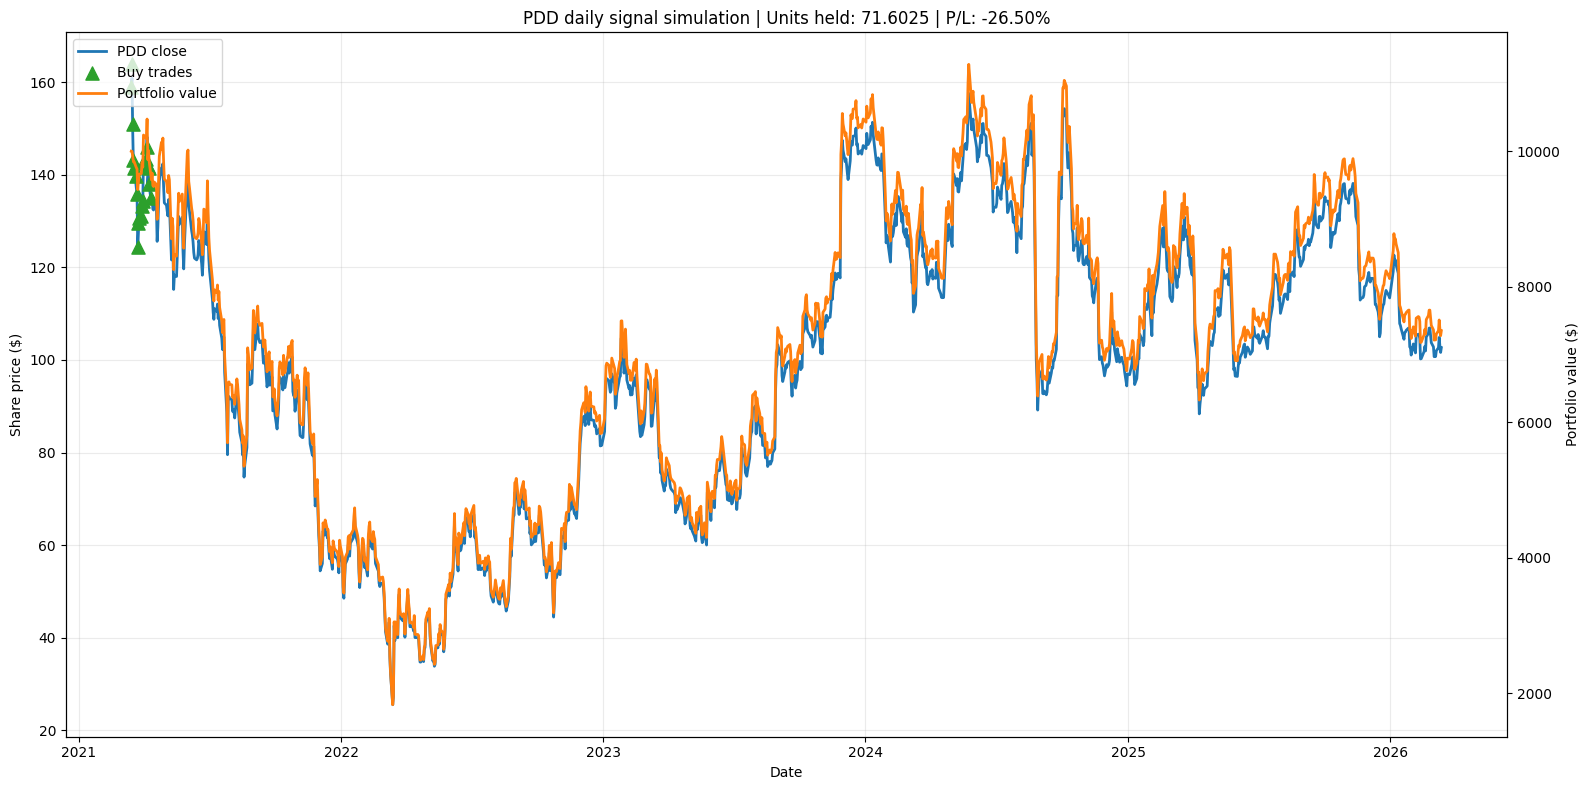

In [9]:
price_history = simulation_result["price_history"].copy()
daily_history = simulation_result["daily_history"].copy()
transactions = simulation_result["transactions"].copy()
simulation_summary = simulation_result["summary"].iloc[0]

buy_txns = transactions[transactions["action"] == "BUY"].copy()
sell_txns = transactions[transactions["action"] == "SELL"].copy()

fig, ax_price = plt.subplots(figsize=(16, 8))
ax_price.plot(
    price_history["Date"],
    price_history["Close"],
    color="#1f77b4",
    linewidth=2,
    label=f"{ticker} close",
)

if not buy_txns.empty:
    ax_price.scatter(
        buy_txns["Date"],
        buy_txns["trade_price"],
        color="#2ca02c",
        marker="^",
        s=90,
        label="Buy trades",
        zorder=5,
    )

if not sell_txns.empty:
    ax_price.scatter(
        sell_txns["Date"],
        sell_txns["trade_price"],
        color="#d62728",
        marker="v",
        s=90,
        label="Sell trades",
        zorder=5,
    )

ax_price.set_xlabel("Date")
ax_price.set_ylabel("Share price ($)")
ax_price.grid(alpha=0.25)

ax_portfolio = ax_price.twinx()
ax_portfolio.plot(
    daily_history["Date"],
    daily_history["portfolio_value"],
    color="#ff7f0e",
    linewidth=2,
    label="Portfolio value",
)
ax_portfolio.set_ylabel("Portfolio value ($)")

title = (
    f"{ticker} daily signal simulation | "
    f"Units held: {simulation_summary['units_held']:.4f} | "
    f"P/L: {simulation_summary['profit_loss_pct']:.2f}%"
)
ax_price.set_title(title)

handles_price, labels_price = ax_price.get_legend_handles_labels()
handles_portfolio, labels_portfolio = ax_portfolio.get_legend_handles_labels()
ax_price.legend(handles_price + handles_portfolio, labels_price + labels_portfolio, loc="upper left")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Block 7: Daily Portfolio History


In [10]:
simulation_result["daily_history"][[
    "Date",
    "signal_text",
    "action",
    "trade_units",
    "trade_value",
    "cash_balance",
    "units_held",
    "holdings_value",
    "portfolio_value",
    "profit_loss_pct",
]].tail(60)


,Date,signal_text,action,trade_units,trade_value,cash_balance,units_held,holdings_value,portfolio_value,profit_loss_pct
1196,2025-12-16,WEAK BUY,HOLD,0.0,0.0,0.0,71.602495,7806.103726,7806.103726,-21.938963
1197,2025-12-17,STRONG BUY,HOLD,0.0,0.0,0.0,71.602495,7518.261938,7518.261938,-24.817381
1198,2025-12-18,STRONG BUY,HOLD,0.0,0.0,0.0,71.602495,7574.827974,7574.827974,-24.251720
1199,2025-12-19,STRONG BUY,HOLD,0.0,0.0,0.0,71.602495,7841.189342,7841.189342,-21.588107
1200,2025-12-22,WEAK BUY,HOLD,0.0,0.0,0.0,71.602495,8013.035438,8013.035438,-19.869646
1201,2025-12-23,WEAK BUY,HOLD,0.0,0.0,0.0,71.602495,8023.775375,8023.775375,-19.762246
1202,2025-12-24,WEAK BUY,HOLD,0.0,0.0,0.0,71.602495,8122.587167,8122.587167,-18.774128
1203,2025-12-26,WEAK BUY,HOLD,0.0,0.0,0.0,71.602495,8235.003062,8235.003062,-17.649969
1204,2025-12-29,WEAK BUY,HOLD,0.0,0.0,0.0,71.602495,8173.424873,8173.424873,-18.265751
1205,2025-12-30,WEAK BUY,HOLD,0.0,0.0,0.0,71.602495,8150.512097,8150.512097,-18.494879
